# 1. Текстовое описание набора данных

Для выполнения лабораторной работы был выбран датасет **Iris** из библиотеки `scikit-learn`.

Импортируем библиотеки с помощью команды import.

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")
from sklearn.datasets import load_iris


In [2]:
# Загрузка данных
iris = load_iris()

# Создаем DataFrame с данными
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Добавляем целевой признак
data['target'] = iris.target

## 2) Основные характеристики датасета

In [3]:
# Первые 5 строк датасета
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
data.shape

(150, 5)

In [5]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 150


In [6]:
# Список колонок
for column in data.columns:
    print(column)

sepal length (cm)
sepal width (cm)
petal length (cm)
petal width (cm)
target


In [7]:
# Список колонок с типами данных
data.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

In [8]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

sepal length (cm) - 0
sepal width (cm) - 0
petal length (cm) - 0
petal width (cm) - 0
target - 0


In [9]:
# Основные статистические характеристики набора данных
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
# Определим уникальные значения для целевого признака
data['target'].unique()

array([0, 1, 2])

Целевой признак содержит три класса: 0, 1 и 2.


## 3) Визуальное исследование датасета

Для визуального исследования могут быть использованы различные виды диаграмм. Мы построим несколько вариантов, которые используются достаточно часто.

### Диаграмма рассеяния

Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Не предполагается, что значения упорядочены (например, по времени).

<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

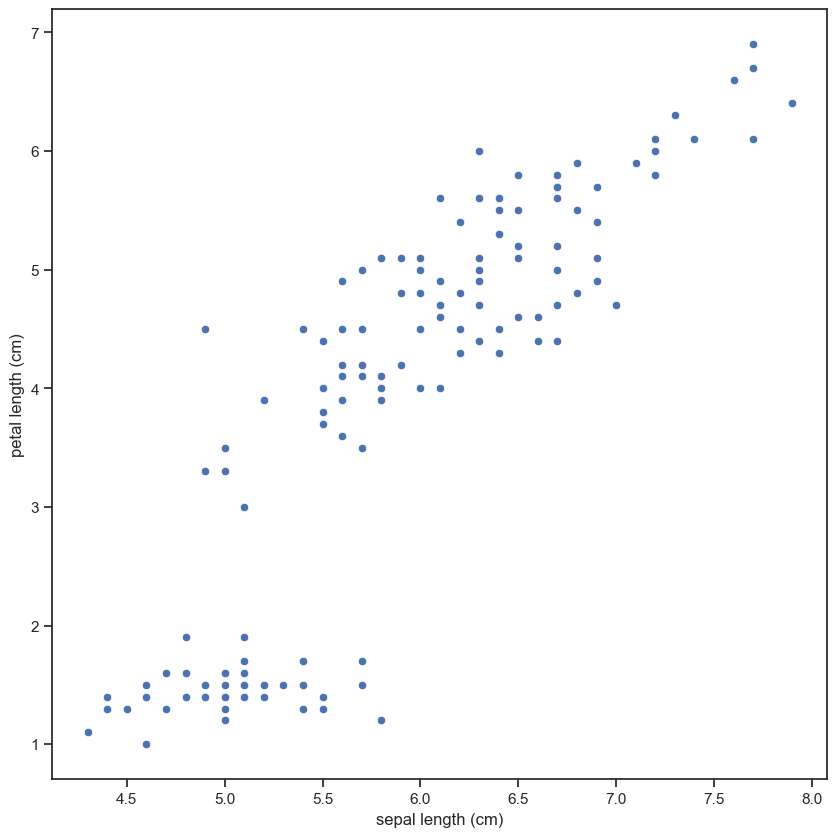

In [11]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, x='sepal length (cm)', y='petal length (cm)', data=data)

Наблюдается положительная корреляция между длиной чашелистика и длиной лепестка: с увеличением длины чашелистика (по оси X) в целом увеличивается и длина лепестка (по оси Y).
Разброс точек указывает на то, что хотя общая тенденция присутствует, есть и индивидуальные отклонения — не все растения с одинаковой длиной чашелистика имеют одинаковую длину лепестка.

посмотрим на влияние целевой функции

<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

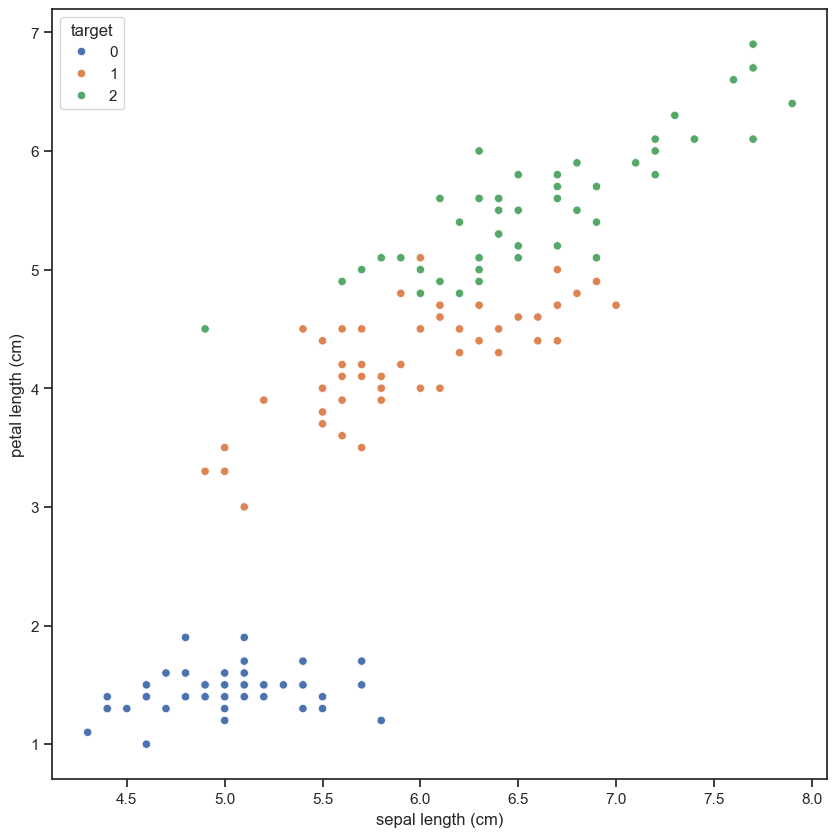

In [12]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, x='sepal length (cm)', y='petal length (cm)', data=data, hue='target', palette='deep')

### Гистограмма

Позволяет оценить плотность вероятности распределения данных.

Text(0.5, 1.0, 'Распределение длины чашелистика')

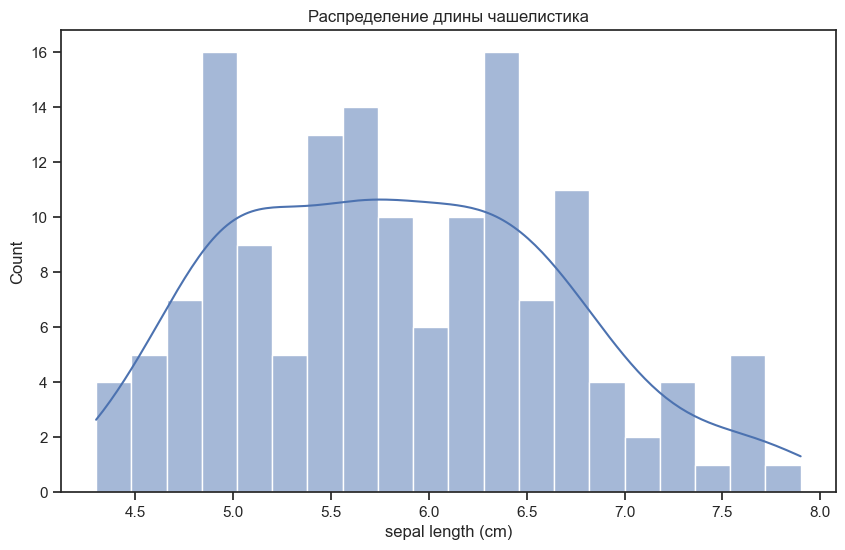

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data['sepal length (cm)'], bins=20, kde=True)
plt.title('Распределение длины чашелистика')

Комбинация гистограмм и диаграмм рассеивания.

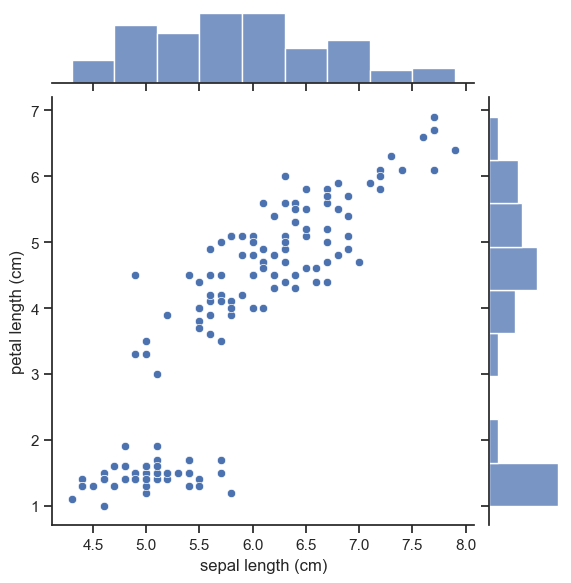

In [14]:
sns.jointplot(x='sepal length (cm)', y='petal length (cm)', data=data)

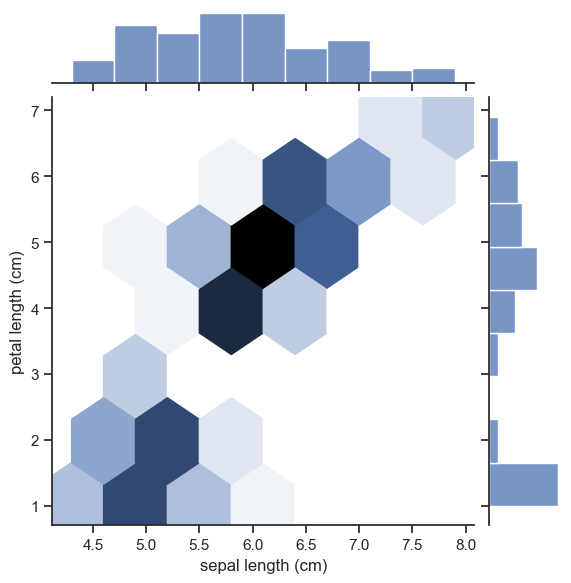

In [15]:
sns.jointplot(x='sepal length (cm)', y='petal length (cm)', data=data, kind="hex")

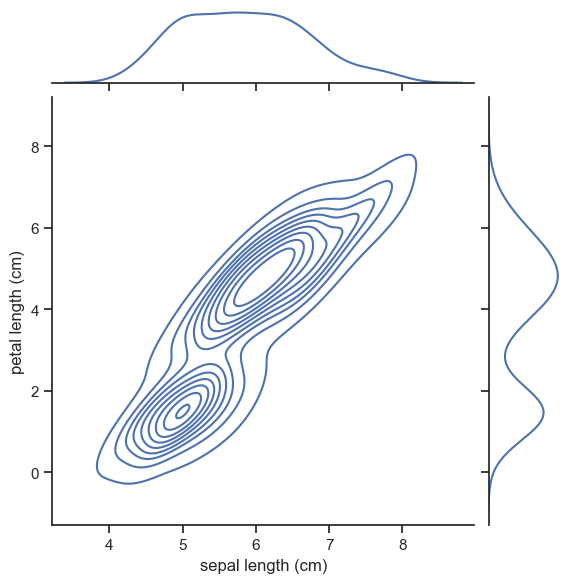

In [16]:
sns.jointplot(x='sepal length (cm)', y='petal length (cm)', data=data, kind="kde")

### "Парные диаграммы" (Pairplot)

Комбинация гистограмм и диаграмм рассеивания для всего набора данных.

Выводится матрица графиков. На пересечении строки и столбца, которые соответствуют двум показателям, строится диаграмма рассеивания. На главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.

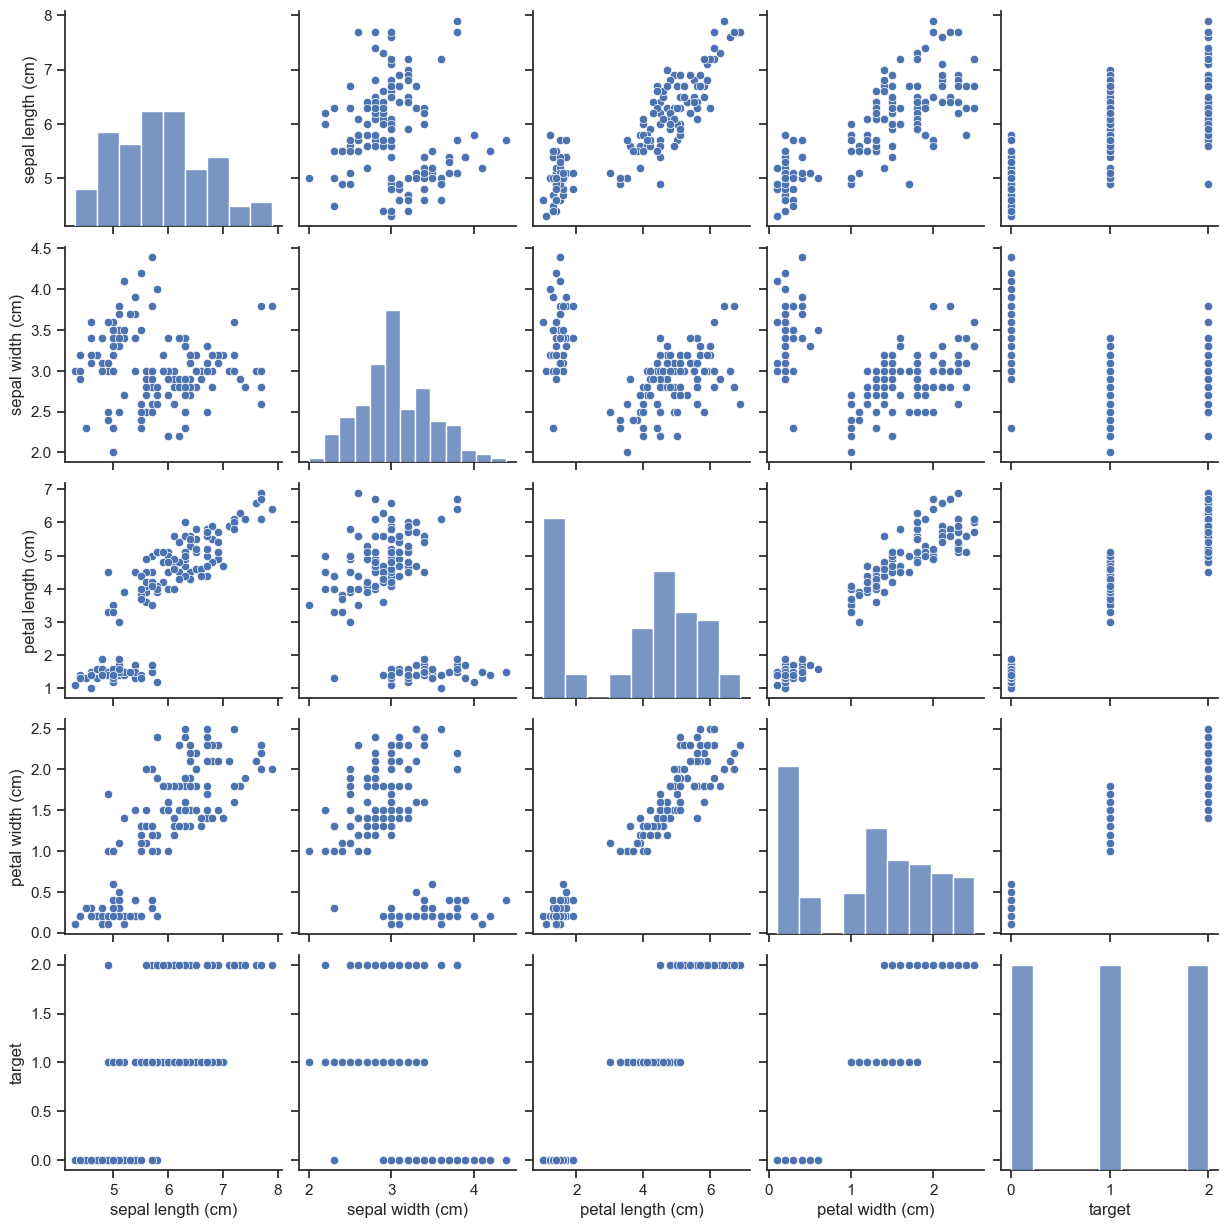

In [17]:
selected_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']
sns.pairplot(data[selected_features])

С помощью параметра `hue` возможна группировка по значениям какого-либо признака (в нашем случае - по виду ириса).

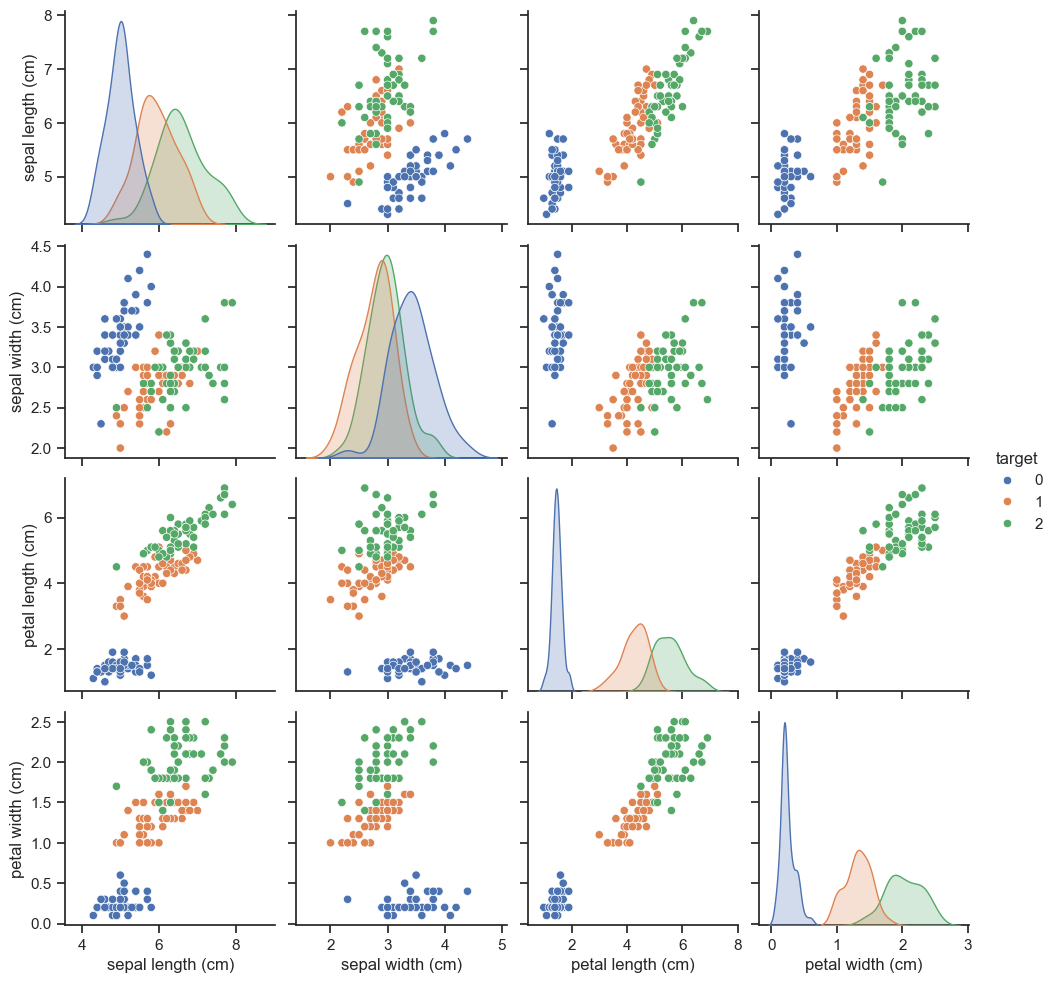

In [18]:
sns.pairplot(data[selected_features], hue="target", palette='deep')

### Ящик с усами (Boxplot)

Отображает одномерное распределение вероятности.

<Axes: xlabel='sepal length (cm)'>

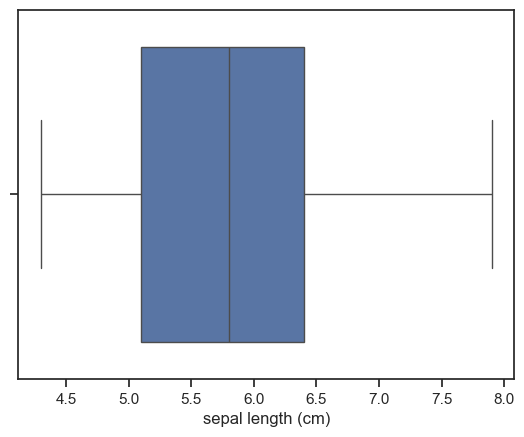

In [19]:
sns.boxplot(x=data['sepal length (cm)'])

<Axes: ylabel='sepal length (cm)'>

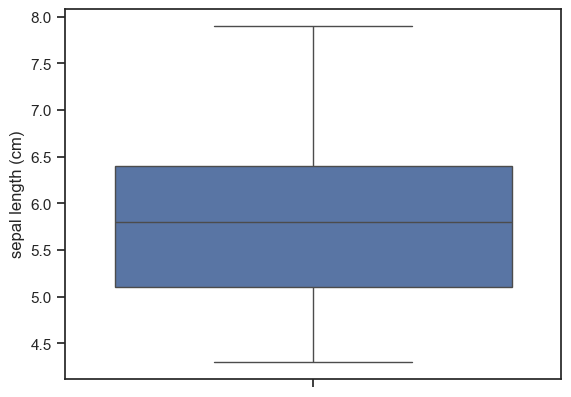

In [20]:
# По вертикали
sns.boxplot(y=data['sepal length (cm)'])

<Axes: xlabel='target', ylabel='sepal length (cm)'>

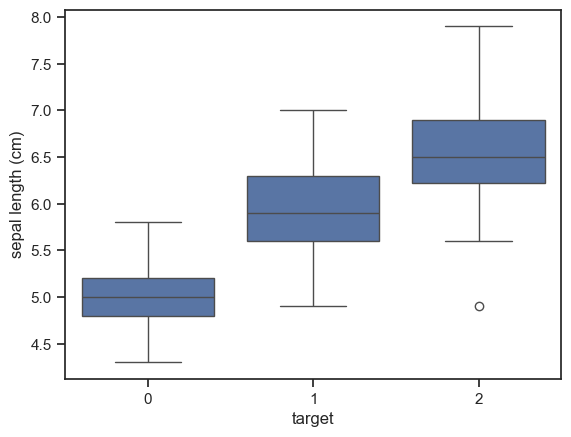

In [21]:
sns.boxplot(x='target', y='sepal length (cm)', data=data)

### Violin plot (Скрипичная диаграмма)

Похожа на предыдущую диаграмму, но по краям отображаются распределения плотности - https://en.wikipedia.org/wiki/Kernel_density_estimation

<Axes: xlabel='sepal length (cm)'>

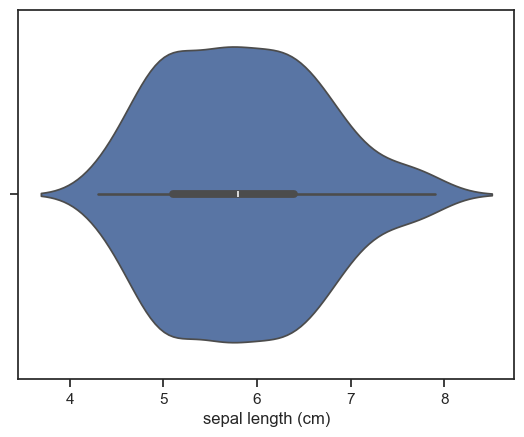

In [22]:
sns.violinplot(x=data['sepal length (cm)'])

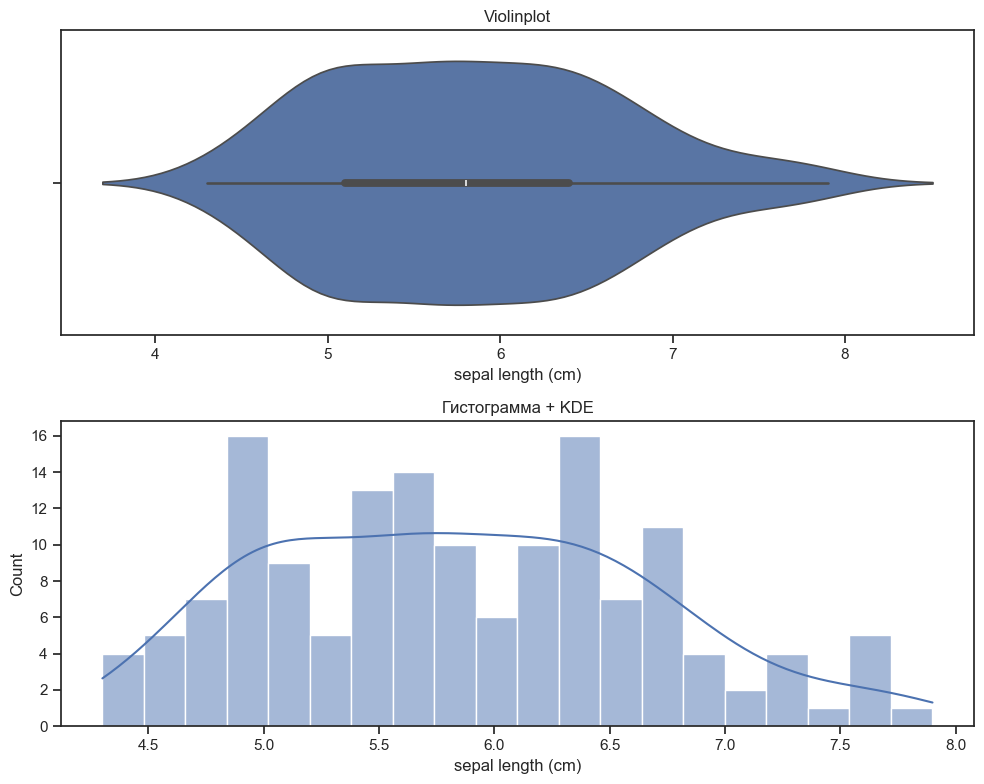

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))
sns.violinplot(ax=ax[0], x=data['sepal length (cm)'])
sns.histplot(ax=ax[1], x=data['sepal length (cm)'], bins=20, kde=True)
ax[0].set_title('Violinplot')
ax[1].set_title('Гистограмма + KDE')
plt.tight_layout()


Из приведенных графиков видно, что violinplot действительно показывает распределение плотности.

<Axes: xlabel='target', ylabel='sepal length (cm)'>

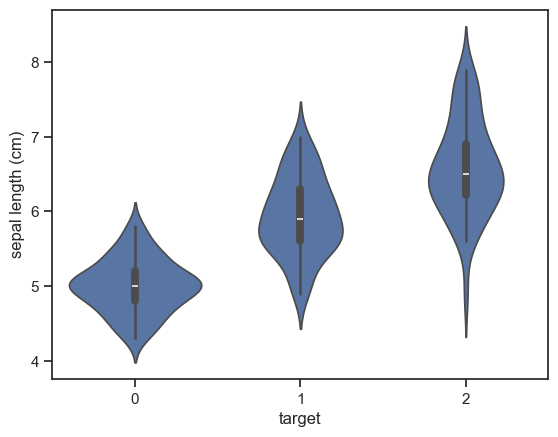

In [24]:
# Распределение параметра alcohol, сгруппированное по target
sns.violinplot(x='target', y='sepal length (cm)', data=data)

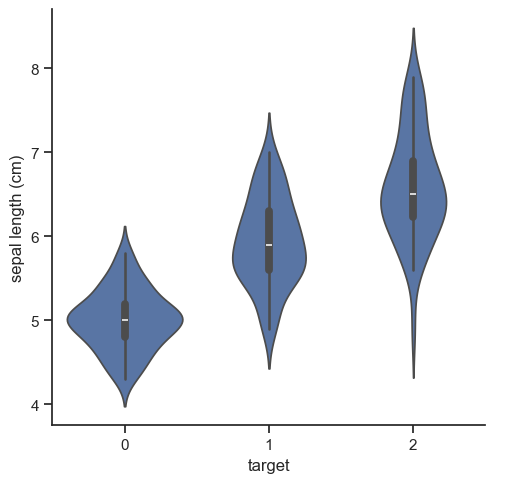

In [25]:
sns.catplot(y='sepal length (cm)', x='target', data=data, kind="violin", split=False)

## 4) Информация о корреляции признаков

Проверка корреляции признаков позволяет решить две задачи:

1.  Понять какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка "target"). Именно эти признаки будут наиболее информативными для моделей машинного обучения.
2.  Понять какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, очень плохо влияют на качество моделей. Поэтому если несколько признаков линейно зависимы, то для построения модели из них выбирают какой-то один признак.

In [26]:
# Вычисляем корреляционную матрицу (исключая целевую переменную)
# Для удобства включим target обратно, чтобы увидеть корреляцию признаков с ним
corr_matrix = data.corr()
corr_matrix

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


In [27]:
# Описание метода corr - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html
# По умолчанию используется коэффициент корреляции Пирсона. Можно также использовать Кендалла и Спирмена.

print("Корреляция Пирсона (по умолчанию):")
display(data.corr(method='pearson').round(3))

print("\nКорреляция Кендалла:")
display(data.corr(method='kendall').round(3))

print("\nКорреляция Спирмена:")
display(data.corr(method='spearman').round(3))

Корреляция Пирсона (по умолчанию):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000,-0.118,0.872,0.818,0.783
sepal width (cm),-0.118,1.000,-0.428,-0.366,-0.427
petal length (cm),0.872,-0.428,1.000,0.963,0.949
petal width (cm),0.818,-0.366,0.963,1.000,0.957
target,0.783,-0.427,0.949,0.957,1.000



Корреляция Кендалла:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000,-0.077,0.719,0.655,0.670
sepal width (cm),-0.077,1.000,-0.186,-0.157,-0.338
petal length (cm),0.719,-0.186,1.000,0.807,0.823
petal width (cm),0.655,-0.157,0.807,1.000,0.840
target,0.670,-0.338,0.823,0.840,1.000



Корреляция Спирмена:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000,-0.167,0.882,0.834,0.798
sepal width (cm),-0.167,1.000,-0.310,-0.289,-0.440
petal length (cm),0.882,-0.310,1.000,0.938,0.935
petal width (cm),0.834,-0.289,0.938,1.000,0.938
target,0.798,-0.440,0.935,0.938,1.000


В случае большого количества признаков анализ числовой корреляционной матрицы становится неудобен.

Для визуализации корреляционной матрицы будем использовать "тепловую карту" heatmap, которая показывает степень корреляции различными цветами.

<Axes: >

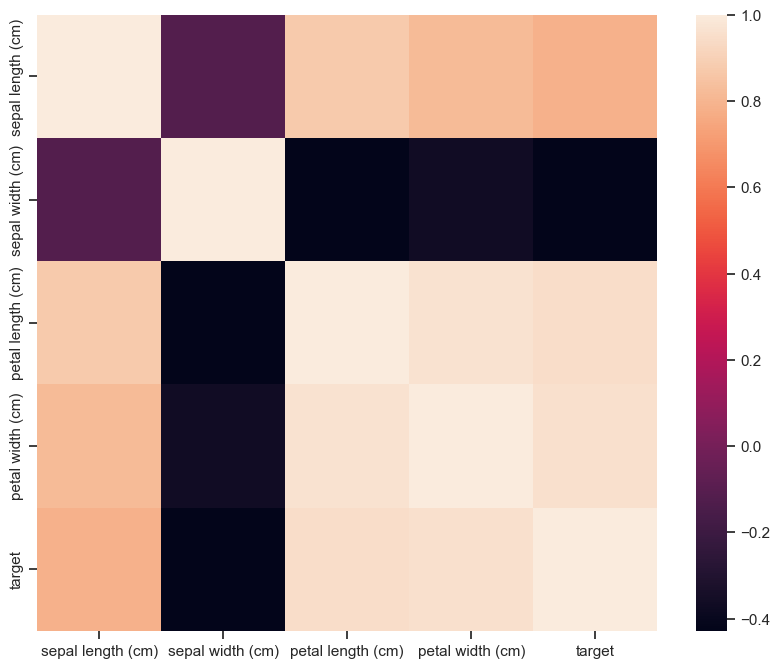

In [28]:
# Используем метод heatmap библиотеки seaborn - https://seaborn.pydata.org/generated/seaborn.heatmap.html
plt.figure(figsize=(10,8))
sns.heatmap(data.corr())

<Axes: >

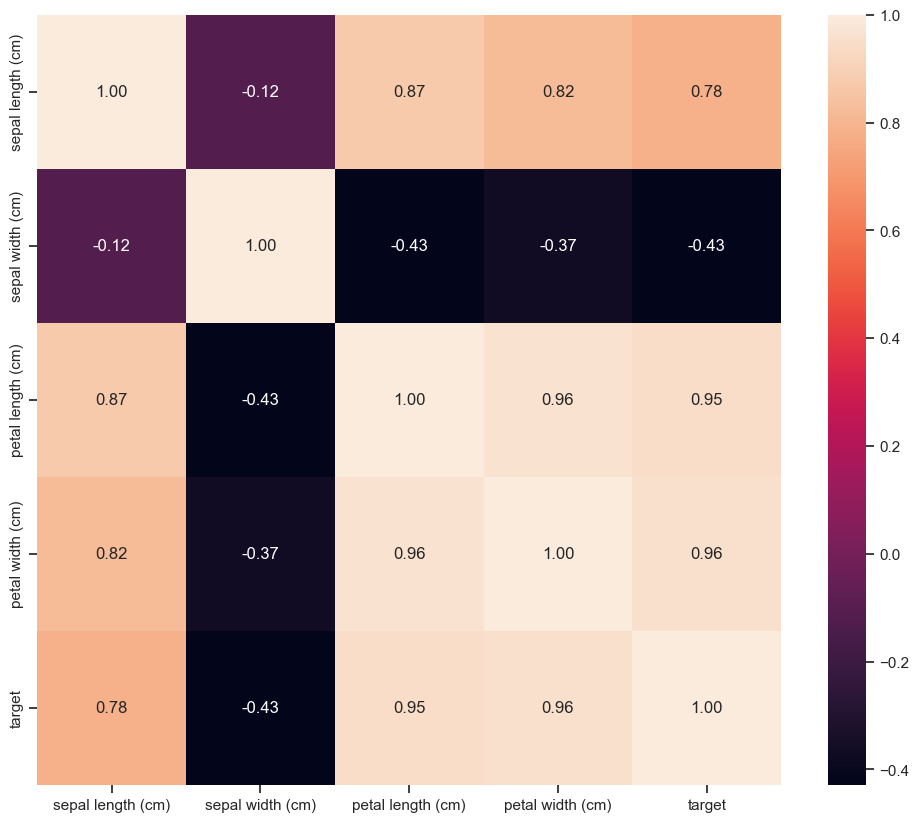

In [29]:
# Вывод значений в ячейках
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), annot=True, fmt='.2f')

<Axes: >

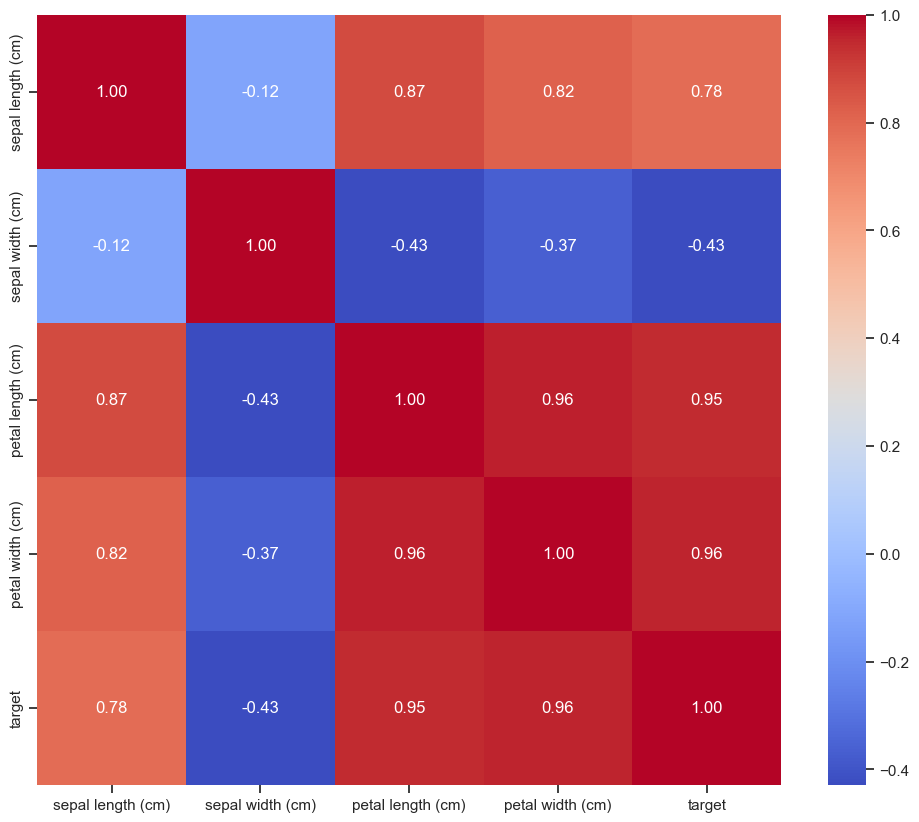

In [30]:
# Изменение цветовой гаммы
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm', annot=True, fmt='.2f')

<Axes: >

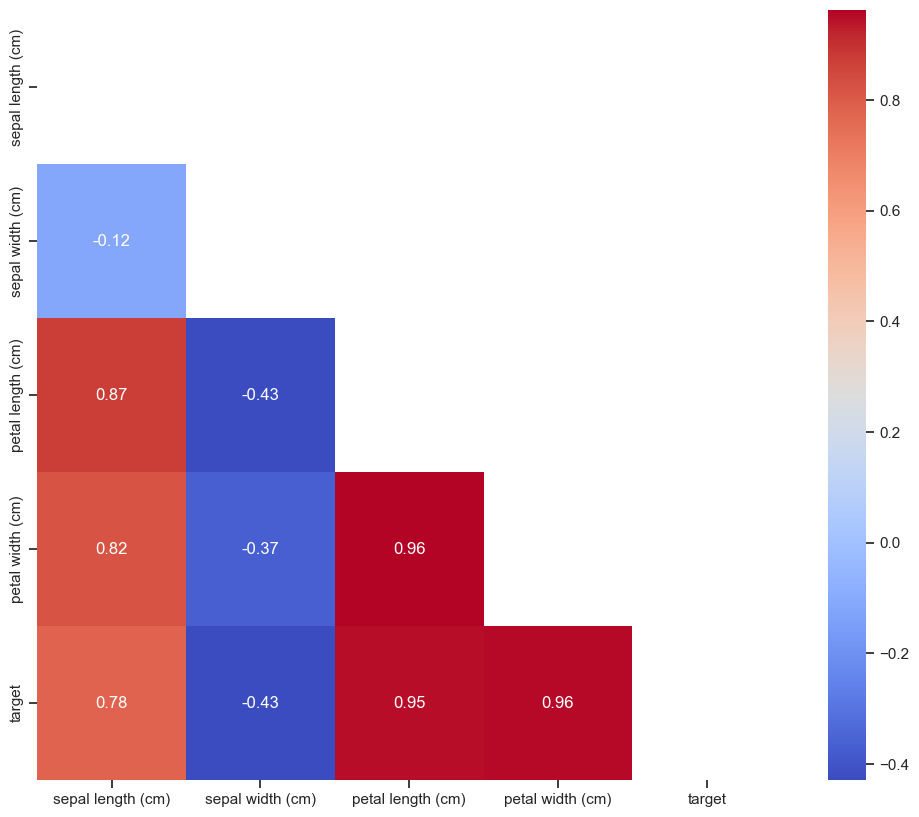

In [31]:
# Треугольный вариант матрицы (верхняя часть)
# Создаем маску для верхней части матрицы
mask = np.triu(np.ones_like(data.corr(), dtype=bool))
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm')

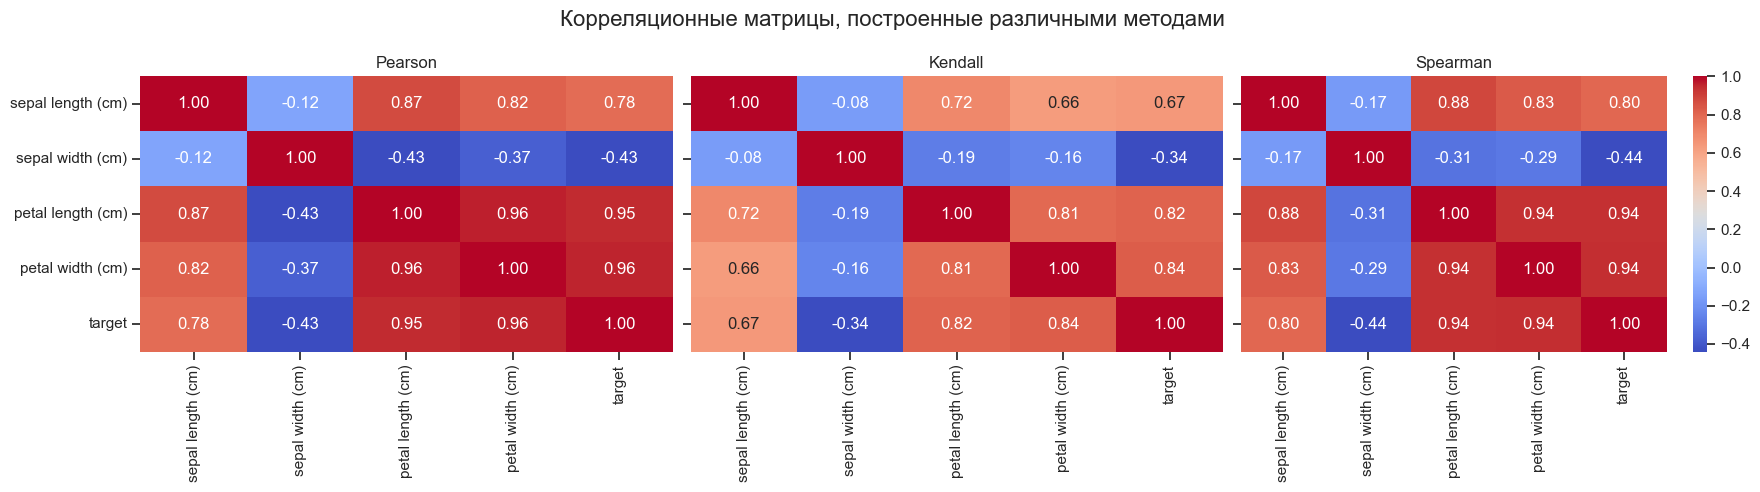

In [32]:
# Сравнение корреляционных матриц, построенных разными методами
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(18,5))

sns.heatmap(data.corr(method='pearson'), ax=ax[0], annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
sns.heatmap(data.corr(method='kendall'), ax=ax[1], annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
sns.heatmap(data.corr(method='spearman'), ax=ax[2], annot=True, fmt='.2f', cmap='coolwarm')

fig.suptitle('Корреляционные матрицы, построенные различными методами', fontsize=16)
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')
plt.tight_layout()

### Тепловая карта с указанием размера

*   Функция `plt.subplots` создает область окна нужного размера, в которую может выводиться график.
*   Параметр `figsize=(размер по горизонтали, размер по вертикали)`.
*   По умолчанию размер задается в дюймах.
*   Функция `sns.heatmap` содержит параметр `ax=ax`, который ссылается на область, созданную `plt.subplots`, поэтому график выводится в данной области.

<Axes: >

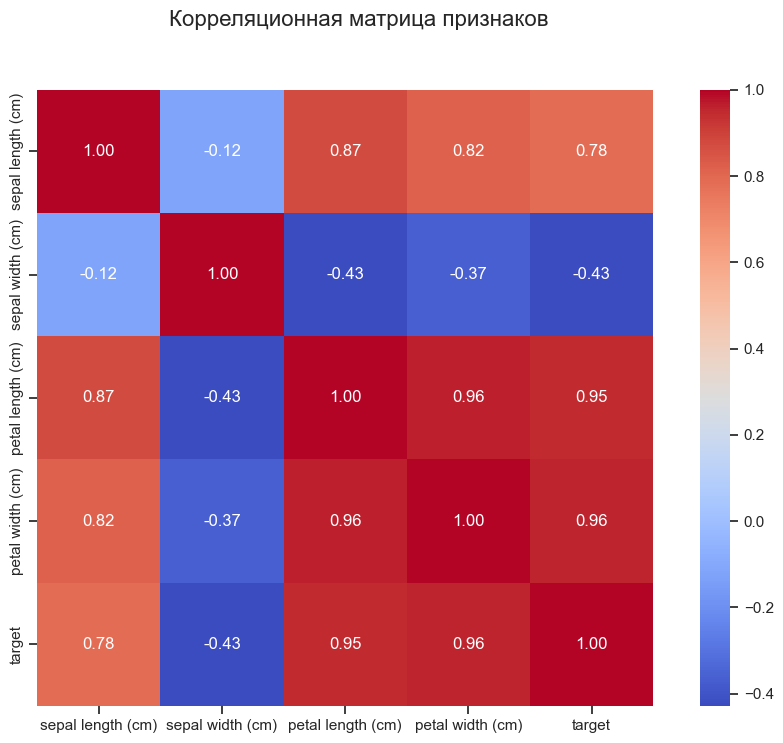

In [33]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(12,8))
fig.suptitle('Корреляционная матрица признаков', fontsize=16)
sns.heatmap(data.corr(), ax=ax, annot=True, fmt='.2f', cmap='coolwarm', square=True)